# Gaussian Mixture Model (GMM) Clustering

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [4]:
# 1. LOAD DATA
start_time = time.time()

X = pd.read_csv('finalclusteringdataset.csv')

features = ['trip_frequency', 'average_booking_value',
            'destination_diversity', 'session_duration', 'search_behavior']

X = X[features]

In [5]:
# 2. TRAIN / TEST SPLIT
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 80001 | Test size: 20001


In [6]:
# 3. SELECT BEST COVARIANCE TYPE (on a sample)
print("\n Selecting Best Covariance Type ")
sample = X_train.sample(min(20000, len(X_train)), random_state=0)
cov_types = ['full', 'tied', 'diag', 'spherical']
best_bic, best_cov = np.inf, None

for cov in cov_types:
    try:
        gmm_tmp = GaussianMixture(n_components=3, covariance_type=cov,
                                  random_state=42, n_init=3)
        gmm_tmp.fit(sample)
        bic = gmm_tmp.bic(sample)
        print(f"  {cov:10s}  BIC = {bic:.2f}")
        if bic < best_bic:
            best_bic, best_cov = bic, cov
    except Exception as e:
        print(f"  {cov:10s}  Failed: {e}")

print(f"\nBest covariance type: {best_cov}  (BIC={best_bic:.2f})")


 Selecting Best Covariance Type 


c:\Users\vansh\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\vansh\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\vansh\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\vansh\AppData\Local\Programs\Python\Pytho

  full        BIC = 669580.36
  tied        BIC = 669325.44
  diag        BIC = 669325.86
  spherical   BIC = 996328.89

Best covariance type: tied  (BIC=669325.44)



 Finding Optimal Number of Components 
  n=2  BIC=669489.71  AIC=669284.22
  n=3  BIC=669325.44  AIC=669072.53
  n=4  BIC=669404.55  AIC=669104.21
  n=5  BIC=669357.83  AIC=669010.08
  n=6  BIC=669396.76  AIC=669001.58
  n=7  BIC=669359.24  AIC=668916.64
  n=8  BIC=669355.00  AIC=668864.98
  n=9  BIC=668390.77  AIC=667853.33
  n=10  BIC=668636.71  AIC=668051.86

Optimal components (BIC): 9


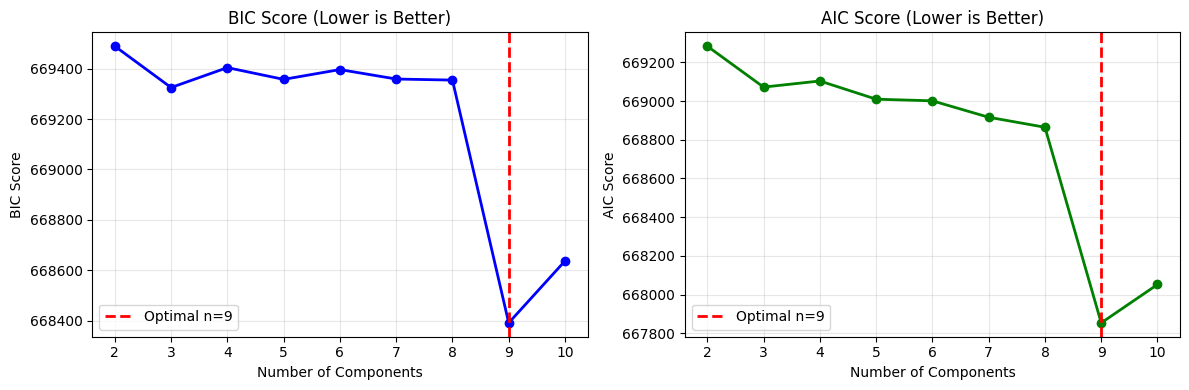

In [7]:
# 4. FIND OPTIMAL NUMBER OF COMPONENTS via BIC
print("\n Finding Optimal Number of Components ")
n_range = range(2, 11)
bic_scores, aic_scores = [], []

for n in n_range:
    gmm = GaussianMixture(n_components=n, covariance_type=best_cov,
                          random_state=42, n_init=3, max_iter=200)
    gmm.fit(sample)
    bic_scores.append(gmm.bic(sample))
    aic_scores.append(gmm.aic(sample))
    print(f"  n={n}  BIC={bic_scores[-1]:.2f}  AIC={aic_scores[-1]:.2f}")

optimal_n = list(n_range)[np.argmin(bic_scores)]
print(f"\nOptimal components (BIC): {optimal_n}")

# BIC / AIC Plot

n_components_range = list(n_range)  

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# BIC Plot
ax1.plot(n_components_range, bic_scores, 'bo-', linewidth=2, markersize=6)
ax1.axvline(optimal_n, color='red', linestyle='--', linewidth=2,
            label=f'Optimal n={optimal_n}')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('BIC Score')
ax1.set_title('BIC Score (Lower is Better)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# AIC Plot
ax2.plot(n_components_range, aic_scores, 'go-', linewidth=2, markersize=6)
ax2.axvline(optimal_n, color='red', linestyle='--', linewidth=2,
            label=f'Optimal n={optimal_n}')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('AIC Score')
ax2.set_title('AIC Score (Lower is Better)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bic_aic_plot.png', dpi=150)
plt.show()

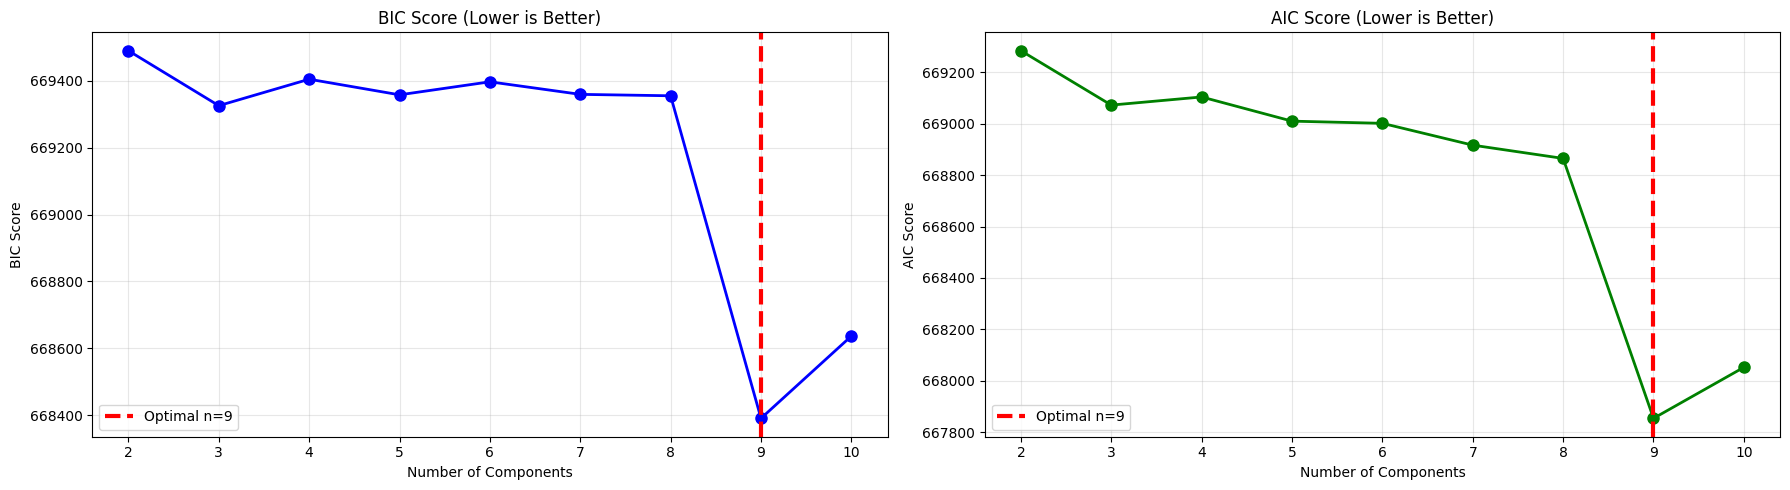

In [8]:
# YAHAN SE SHURU HOTA HAI WOH CELL
n_components_range = list(n_range)   # ← BUS YEH LINE ADD KARO SABSE UPAR

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# BIC Plot
axes[0].plot(n_components_range, bic_scores, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(optimal_n, color='red', linestyle='--', linewidth=3,
                label=f'Optimal n={optimal_n}')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('BIC Score')
axes[0].set_title('BIC Score (Lower is Better)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# AIC Plot
axes[1].plot(n_components_range, aic_scores, 'go-', linewidth=2, markersize=8)
axes[1].axvline(optimal_n, color='red', linestyle='--', linewidth=3,
                label=f'Optimal n={optimal_n}')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('AIC Score')
axes[1].set_title('AIC Score (Lower is Better)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# 5. TRAIN FINAL GMM ON FULL TRAINING DATA
print(f"\n=== Training Final GMM (n={optimal_n}, cov={best_cov}) ===")
gmm_final = GaussianMixture(n_components=optimal_n, covariance_type=best_cov,
                             random_state=42, n_init=10, max_iter=300, verbose=1)
gmm_final.fit(X_train)
print("✔ Model trained")


=== Training Final GMM (n=9, cov=tied) ===
Initialization 0
  Iteration 10
Initialization converged.
Initialization 1
Initialization converged.
Initialization 2
Initialization converged.
Initialization 3
  Iteration 10
Initialization converged.
Initialization 4
Initialization converged.
Initialization 5
Initialization converged.
Initialization 6
  Iteration 10
Initialization converged.
Initialization 7
Initialization converged.
Initialization 8
  Iteration 10
Initialization converged.
Initialization 9
Initialization converged.
✔ Model trained


In [10]:
# 6. PREDICT CLUSTERS
train_labels = gmm_final.predict(X_train)
test_labels  = gmm_final.predict(X_test)

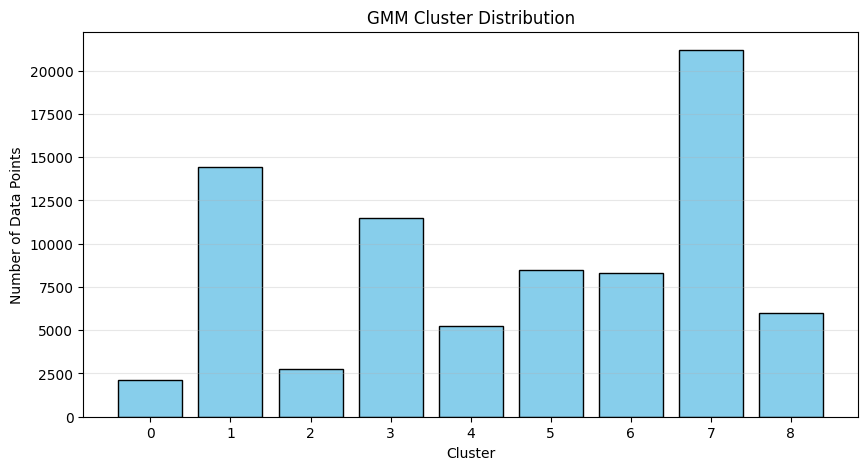


Cluster Distribution:
Cluster 0: 2130 samples (2.13%)
Cluster 1: 14406 samples (14.41%)
Cluster 2: 2741 samples (2.74%)
Cluster 3: 11490 samples (11.49%)
Cluster 4: 5251 samples (5.25%)
Cluster 5: 8488 samples (8.49%)
Cluster 6: 8307 samples (8.31%)
Cluster 7: 21193 samples (21.19%)
Cluster 8: 5995 samples (5.99%)


In [11]:
# Cluster distribution
unique, counts = np.unique(train_labels, return_counts=True)
plt.figure(figsize=(10, 5))
plt.bar(unique, counts, color='skyblue', edgecolor='black')
plt.xlabel('Cluster')
plt.ylabel('Number of Data Points')
plt.title('GMM Cluster Distribution')
plt.xticks(unique)
plt.grid(axis='y', alpha=0.3)
plt.show()

print('\nCluster Distribution:')
for cluster, count in zip(unique, counts):
    print(f'Cluster {cluster}: {count} samples ({count/len(X)*100:.2f}%)')

In [12]:
# Compare different covariance types
optimal_components = optimal_n

covariance_types = ['full', 'tied', 'diag', 'spherical']
silhouette_scores_by_cov = {}

print('\nSilhouette scores by covariance type:')
for cov_type in covariance_types:
    gmm_cov = GaussianMixture(n_components=optimal_components, covariance_type=cov_type, random_state=42, n_init=10)
    labels_cov = gmm_cov.fit_predict(X)
    score = silhouette_score(X, labels_cov)
    silhouette_scores_by_cov[cov_type] = score
    print(f'{cov_type}: {score:.4f}')


Silhouette scores by covariance type:
full: -0.1152
tied: 0.3747
diag: 0.2075
spherical: 0.3782


In [13]:

# 7. EVALUATION SCORES (Train & Test)
# Use a sample for silhouette (it's slow on large data)
sample_idx_tr = np.random.choice(len(X_train), min(10000, len(X_train)), replace=False)
sample_idx_te = np.random.choice(len(X_test),  min(10000, len(X_test)),  replace=False)

sil_train = silhouette_score(X_train.iloc[sample_idx_tr], train_labels[sample_idx_tr])
sil_test  = silhouette_score(X_test.iloc[sample_idx_te],  test_labels[sample_idx_te])
db_train  = davies_bouldin_score(X_train, train_labels)
db_test   = davies_bouldin_score(X_test,  test_labels)

print("\n=== Evaluation Scores ===")
print(f"  Silhouette  — Train: {sil_train:.4f}  |  Test: {sil_test:.4f}")
print(f"  Davies-Bouldin — Train: {db_train:.4f}  |  Test: {db_test:.4f}")
print(f"  BIC (train): {gmm_final.bic(X_train):.2f}")
print(f"  Converged: {gmm_final.converged_}  |  Iterations: {gmm_final.n_iter_}")


=== Evaluation Scores ===
  Silhouette  — Train: 0.3708  |  Test: 0.3719
  Davies-Bouldin — Train: 0.8263  |  Test: 0.8338
  BIC (train): 2672132.39
  Converged: True  |  Iterations: 12


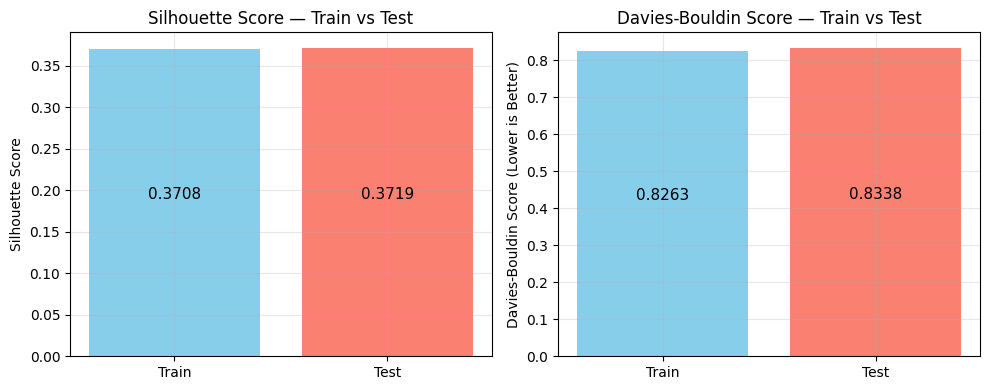

In [14]:
# 8. GRAPH 1 — Silhouette & Davies-Bouldin (Train vs Test)
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Train', 'Test'], [sil_train, sil_test], color=['skyblue', 'salmon'])
for ax_bar, val in zip(axes[0].patches, [sil_train, sil_test]):
    axes[0].text(ax_bar.get_x() + ax_bar.get_width()/2, ax_bar.get_height()/2,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11)
axes[0].set_title('Silhouette Score — Train vs Test')
axes[0].set_ylabel('Silhouette Score')
axes[0].grid(True, alpha=0.3)

axes[1].bar(['Train', 'Test'], [db_train, db_test], color=['skyblue', 'salmon'])
for ax_bar, val in zip(axes[1].patches, [db_train, db_test]):
    axes[1].text(ax_bar.get_x() + ax_bar.get_width()/2, ax_bar.get_height()/2,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11)
axes[1].set_title('Davies-Bouldin Score — Train vs Test')
axes[1].set_ylabel('Davies-Bouldin Score (Lower is Better)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('silhouette_davies_comparison.png', dpi=150)
plt.show()

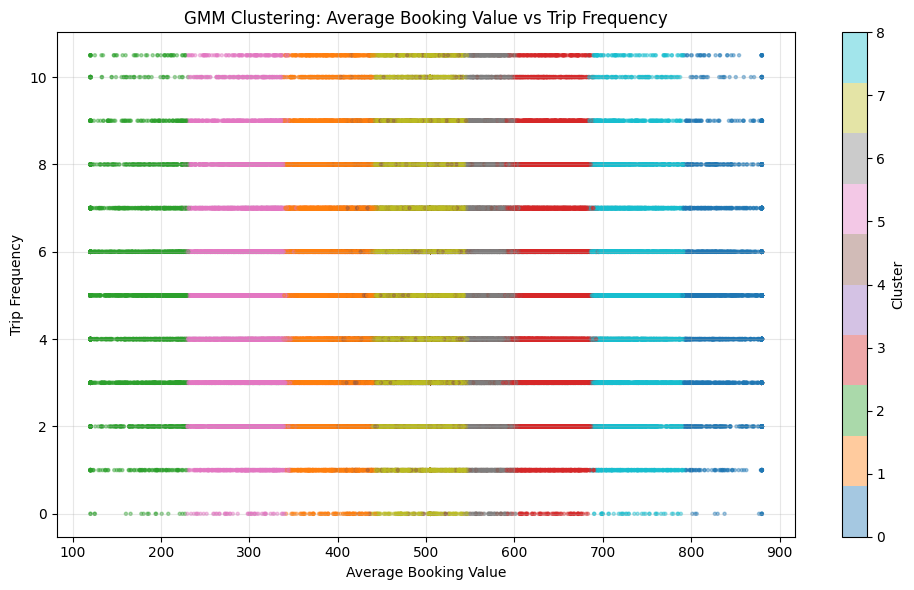

In [15]:

# 9. GRAPH 2 — Avg Booking Value vs Trip Frequency
X_train_plot = X_train.copy()
X_train_plot['Cluster'] = train_labels

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_train_plot['average_booking_value'],
                      X_train_plot['trip_frequency'],
                      c=X_train_plot['Cluster'], cmap='tab10', alpha=0.4, s=5)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Average Booking Value')
plt.ylabel('Trip Frequency')
plt.title('GMM Clustering: Average Booking Value vs Trip Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('booking_vs_frequency.png', dpi=150)
plt.show()

In [16]:

execution_time = time.time() - start_time

X_result = X_train.copy()
X_result['Cluster'] = train_labels
for i in range(optimal_n):
    X_result[f'Cluster_{i}_Probability'] = gmm_final.predict_proba(X_train)[:, i]

X_result.to_csv('gmm_results.csv', index=False)

print(f"\n✔ Results saved to gmm_results.csv")
print(f"✔ Execution time: {execution_time:.2f} seconds")
print(f"\n{'='*50}")
print("GAUSSIAN MIXTURE MODEL CLUSTERING SUMMARY")
print(f"{'='*50}")
print(f"Covariance Type   : {best_cov}")
print(f"Optimal Components: {optimal_n}")
print(f"Silhouette Score  : Train={sil_train:.4f}  Test={sil_test:.4f}")
print(f"Davies-Bouldin    : Train={db_train:.4f}  Test={db_test:.4f}")
print(f"BIC Score         : {gmm_final.bic(X_train):.2f}")
print(f"Model Converged   : {gmm_final.converged_}")

unique, counts = np.unique(train_labels, return_counts=True)
print("\nCluster Distribution (Train):")
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} samples ({count/len(X_train)*100:.1f}%)")


✔ Results saved to gmm_results.csv
✔ Execution time: 669.93 seconds

GAUSSIAN MIXTURE MODEL CLUSTERING SUMMARY
Covariance Type   : tied
Optimal Components: 9
Silhouette Score  : Train=0.3708  Test=0.3719
Davies-Bouldin    : Train=0.8263  Test=0.8338
BIC Score         : 2672132.39
Model Converged   : True

Cluster Distribution (Train):
  Cluster 0: 2130 samples (2.7%)
  Cluster 1: 14406 samples (18.0%)
  Cluster 2: 2741 samples (3.4%)
  Cluster 3: 11490 samples (14.4%)
  Cluster 4: 5251 samples (6.6%)
  Cluster 5: 8488 samples (10.6%)
  Cluster 6: 8307 samples (10.4%)
  Cluster 7: 21193 samples (26.5%)
  Cluster 8: 5995 samples (7.5%)
